In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [40]:
raw_shark_df = pd.read_csv("../data/clean_data/top_states.csv")
shark_df = raw_shark_df[raw_shark_df["activity"] != "adrift"] # this activity has a 100% fatality rate, massive outlier
shark_df = raw_shark_df[raw_shark_df["activity"] != "rescuing"] # too few observations
shark_df = shark_df.drop(["sex", "age", "year"], axis=1)

print(shark_df.head(), "\n")

nonfatal_df = shark_df[shark_df["fatal"] == "N"]
fatal_df = shark_df[shark_df["fatal"] == "Y"]

# compute overall statistics
total_attacks = len(shark_df)
total_fatal = len(fatal_df)
total_nonfatal = len(nonfatal_df)
prop_fatal = total_fatal / total_attacks

print(f"Total number of attacks: {total_attacks}")
print(f"Number of fatal attacks: {total_fatal}")
print(f"Number of nonfatal attacks: {total_nonfatal}")
print(f"Overall fatality rate: {prop_fatal:.2%}")

     country              state              activity fatal     time  \
0        usa            florida              swimming     N  morning   
1  australia    new south wales              swimming     N  morning   
2        usa            florida              swimming     N  morning   
3  australia  western australia          dive fishing     Y  morning   
4  australia    new south wales  surfing/bodyboarding     N  evening   

       species  month hemisphere  season  
0          NaN    6.0   northern  summer  
1  great white    6.0   southern  winter  
2         bull    6.0   northern  summer  
3  great white    6.0   southern  winter  
4         bull    5.0   southern    fall   

Total number of attacks: 3411
Number of fatal attacks: 560
Number of nonfatal attacks: 2851
Overall fatality rate: 16.42%


In [41]:
# function to plate fatality rates by different attributes
def fatality_rate_plots(fatal_counts_df, attribute_name: str, max_x=1400, legend_pos="lower right"):

    fig, axes = plt.subplots(1, 2, figsize=(12,4), gridspec_kw={'wspace': 0.1})

    title_word = attribute_name.capitalize()

    # bar chart for totals
    b1 = axes[0].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["nonfatal_count"],
        label="nonfatal"
    )
    b2 = axes[0].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["fatal_count"],
        label="fatal"
    )
    axes[0].bar_label(axes[0].containers[0], labels=fatal_counts_df["total_count"], padding=3)
    axes[0].set_xlim(0, max_x)
    axes[0].legend(loc=legend_pos)


    # bar chart for death rates
    b3 = axes[1].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["fatality_rate"],
        color="gray"
    )
    plt.axvline(x=prop_fatal, color='red', linestyle='--', linewidth=2, label='Overall Fatality Rate')
    axes[1].bar_label(axes[1].containers[0], fmt='%.3f', padding=4)
    axes[1].set_yticks([])
    axes[1].set_xlim(0, 0.5)
    axes[1].legend()


    # set labels and titles
    axes[0].set_ylabel(title_word, fontsize=13)
    axes[0].set_xlabel("Attack Count", fontsize=13)
    axes[1].set_xlabel("Fatality Rate", fontsize=13)
    fig.suptitle(f"Shark Attacks by {title_word}", fontsize=16)

    plt.savefig(f"../figures/fatrate_plots_{attribute_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

### Looking at Activity

In [42]:
activity_counts = fatal_df.groupby("activity").size().to_frame(name="fatal_count").reset_index()
activity_counts["nonfatal_count"] = nonfatal_df.groupby("activity").size().to_list()
activity_counts["total_count"] = activity_counts["fatal_count"] + activity_counts["nonfatal_count"]
activity_counts["fatality_rate"] = activity_counts["fatal_count"] / activity_counts["total_count"]
activity_counts["perc_of_total"] = activity_counts["total_count"] / total_attacks

# drop activities that account for less than 1% of attacks
activity_counts = activity_counts[activity_counts["perc_of_total"] >= 0.01]
activity_counts.drop(["perc_of_total"], axis=1, inplace=True)

# drop adrift due to uncertainty of circumstances
activity_counts = activity_counts[activity_counts["activity"] != "adrift"]

# sort for visuals
activity_counts.sort_values("total_count", ascending=True, inplace=True)

activity_counts

,activity,fatal_count,nonfatal_count,total_count,fatality_rate
0,SUP/foiling,1,36,37,0.027027
5,small watercraft,6,59,65,0.092308
4,fishing,23,105,128,0.179688
2,dive fishing,27,171,198,0.136364
3,diving,54,193,247,0.218623
8,wading,68,361,429,0.158508
7,swimming,217,596,813,0.266913
6,surfing/bodyboarding,79,1139,1218,0.064860


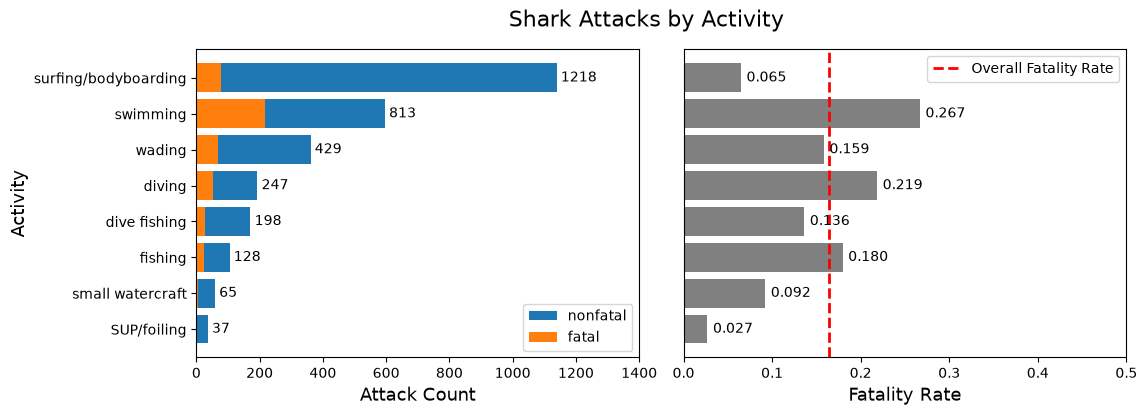

In [43]:
fatality_rate_plots(activity_counts, "activity")

### Looking at Species

In [44]:
species_counts1 = fatal_df.groupby("species").size().to_frame(name="fatal_count").reset_index()
species_counts2 = nonfatal_df.groupby("species").size().to_frame(name="nonfatal_count").reset_index()
species_counts = pd.merge(species_counts2, species_counts1, on="species", how="left").fillna(0)
species_counts["total_count"] = species_counts["fatal_count"] + species_counts["nonfatal_count"]
species_counts["fatality_rate"] = species_counts["fatal_count"] / species_counts["total_count"]
species_counts["perc_of_total"] = species_counts["total_count"] / species_counts["total_count"].sum()

# drop those that account for less than 2% of attacks with species listed
species_counts = species_counts[species_counts["perc_of_total"] >= 0.02]
species_counts.drop(["perc_of_total"], axis=1, inplace=True)

# sort for visuals
species_counts.sort_values("total_count", ascending=True, inplace=True)

species_counts

,species,nonfatal_count,fatal_count,total_count,fatality_rate
12,reef,25,0.0,25.0,0.000000
7,hammerhead,27,1.0,28.0,0.035714
11,raggedtooth,30,0.0,30.0,0.000000
10,nurse,33,1.0,34.0,0.029412
17,wobbegong,39,0.0,39.0,0.000000
14,spinner,51,0.0,51.0,0.000000
0,blacktip,55,0.0,55.0,0.000000
2,bronze whaler,58,4.0,62.0,0.064516
3,bull,119,25.0,144.0,0.173611
15,tiger,153,36.0,189.0,0.190476


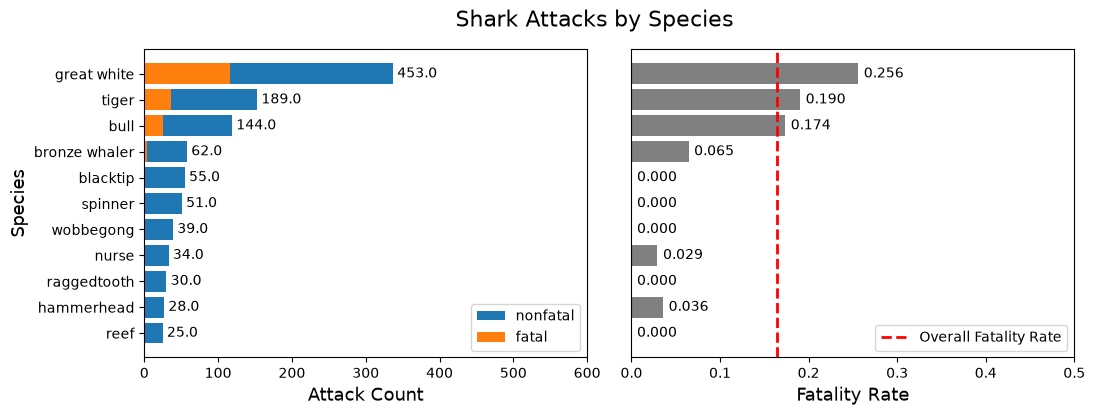

In [28]:
fatality_rate_plots(species_counts, "species", max_x=600)

### Looking at Season

In [29]:
season_counts1 = fatal_df.groupby("season").size().to_frame(name="fatal_count").reset_index()
season_counts2 = nonfatal_df.groupby("season").size().to_frame(name="nonfatal_count").reset_index()
season_counts = pd.merge(season_counts2, season_counts1, on="season", how="left").fillna(0)
season_counts["total_count"] = season_counts["fatal_count"] + season_counts["nonfatal_count"]
season_counts["fatality_rate"] = season_counts["fatal_count"] / season_counts["total_count"]
season_counts["perc_of_total"] = season_counts["total_count"] / season_counts["total_count"].sum()

# drop those that account for less than 2% of attacks with species listed
season_counts = season_counts[season_counts["perc_of_total"] >= 0.02]
season_counts.drop(["perc_of_total"], axis=1, inplace=True)

# sort for visuals
season_counts.sort_values("total_count", ascending=True, inplace=True)

season_counts

,season,nonfatal_count,fatal_count,total_count,fatality_rate
3,winter,271,82,353,0.232295
1,spring,571,94,665,0.141353
0,fall,765,107,872,0.122706
2,summer,1092,216,1308,0.165138


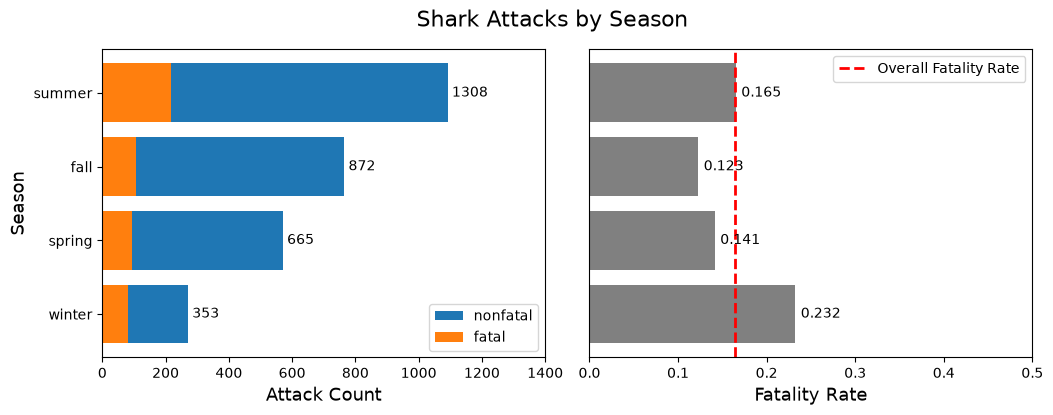

In [30]:
fatality_rate_plots(season_counts, "season", max_x=1400)

### Looking at State

In [31]:
# modified for state plot
def fatality_rate_plots_state(fatal_counts_df, attribute_name: str, max_x=1400, legend_pos="lower right"):

    fig, axes = plt.subplots(1, 2, figsize=(26,8), gridspec_kw={'wspace': 0.1})

    title_word = attribute_name.capitalize()

    # bar chart for totals
    b1 = axes[0].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["nonfatal_count"],
        label="nonfatal"
    )
    b2 = axes[0].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["fatal_count"],
        label="fatal"
    )
    axes[0].bar_label(axes[0].containers[0], labels=fatal_counts_df["total_count"], padding=3, fontsize=6)
    axes[0].tick_params(axis="y", labelsize=6)
    axes[0].set_xlim(0, max_x)
    axes[0].legend(loc=legend_pos)


    # bar chart for death rates
    b3 = axes[1].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["fatality_rate"],
        color="gray"
    )
    plt.axvline(x=prop_fatal, color='red', linestyle='--', linewidth=2, label='Overall Fatality Rate')
    axes[1].bar_label(axes[1].containers[0], fmt='%.3f', padding=4, fontsize=6)
    # axes[1].set_yticks([])
    axes[1].set_xlim(0, 0.8)
    axes[1].tick_params(axis="y", labelsize=6)
    axes[1].legend()


    # set labels and titles
    axes[0].set_ylabel(title_word, fontsize=13)
    axes[0].set_xlabel("Attack Count", fontsize=13)
    axes[1].set_xlabel("Fatality Rate", fontsize=13)
    fig.suptitle(f"Shark Attacks by {title_word}", fontsize=16)

    plt.savefig(f"../figures/fatrate_plots_{attribute_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [32]:
state_counts1 = fatal_df.groupby("state").size().to_frame(name="fatal_count").reset_index()
state_counts2 = nonfatal_df.groupby("state").size().to_frame(name="nonfatal_count").reset_index()

state_counts = state_counts2.merge(state_counts1, on="state", how="left").fillna(0)
state_counts["total_count"] = state_counts["fatal_count"] + state_counts["nonfatal_count"]
state_counts["fatality_rate"] = state_counts["fatal_count"] / state_counts["total_count"]

state_counts.sort_values("total_count", ascending=True, inplace=True)

print(len(state_counts))
state_counts.head()

20


,state,nonfatal_count,fatal_count,total_count,fatality_rate
9,oregon,30,0.0,30.0,0.000000
5,new jersey,24,6.0,30.0,0.200000
14,south island,26,7.0,33.0,0.212121
8,north island,32,14.0,46.0,0.304348
17,victoria,49,13.0,62.0,0.209677


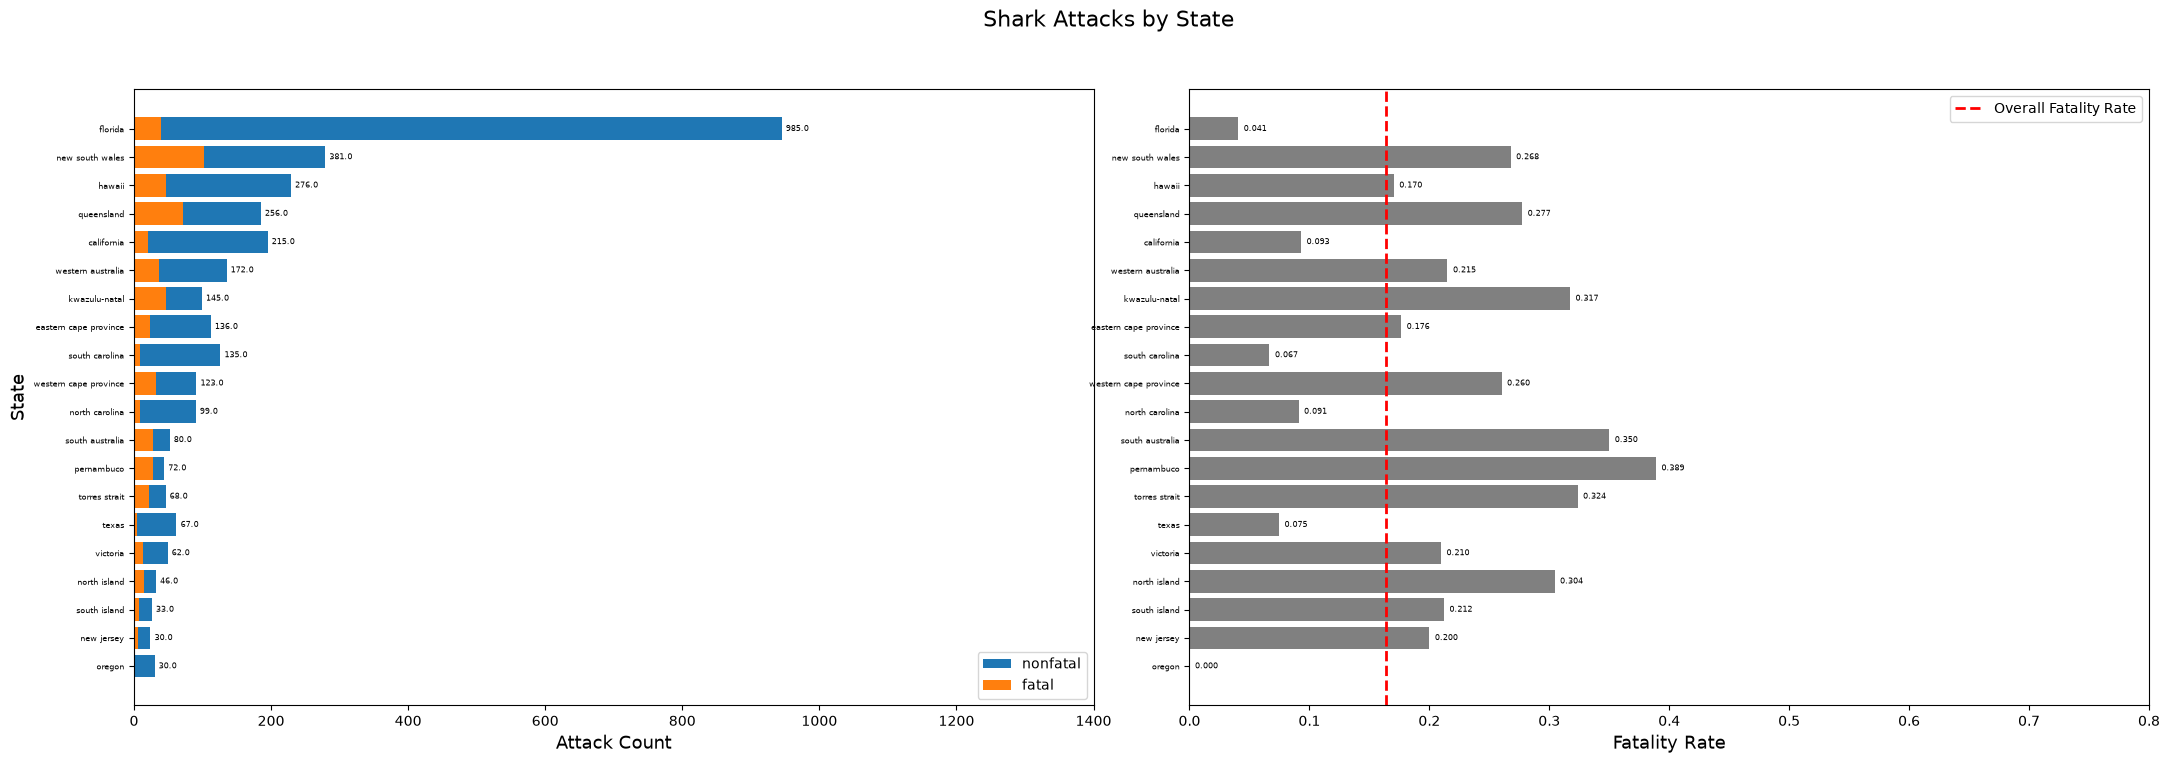

In [33]:
fatality_rate_plots_state(state_counts, attribute_name="state", max_x=1400, legend_pos="lower right")

# Distribution of Activity on Other Variables

### Activity and Season

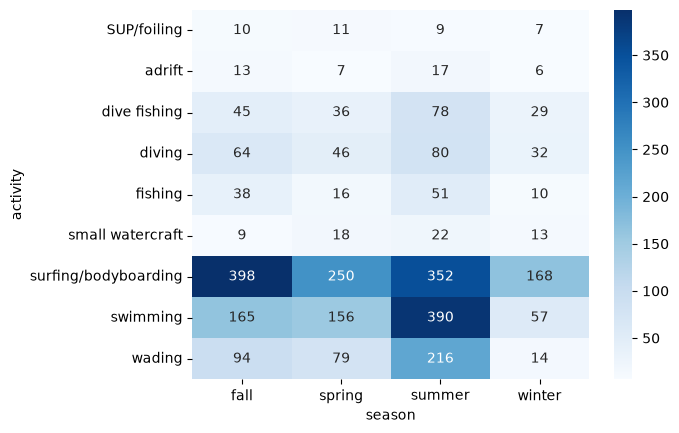

In [34]:
activ_season_ct = pd.crosstab(shark_df["activity"], shark_df["season"])

sns.heatmap(
    activ_season_ct, 
    annot=True, 
    fmt="d", 
    cmap="Blues"
)
plt.show()

## Activity and State

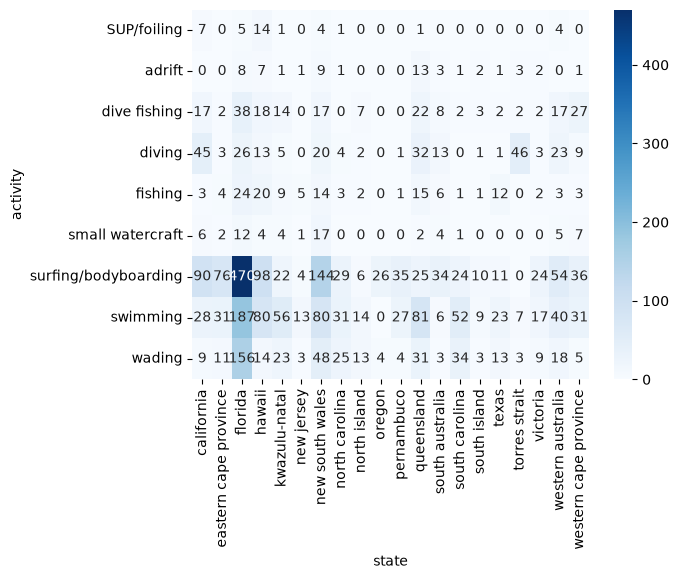

In [35]:
activ_state_ct = pd.crosstab(shark_df["activity"], shark_df["state"])

sns.heatmap(
    activ_state_ct, 
    annot=True, 
    fmt="d", 
    cmap="Blues"
)
plt.show()

# Distribution of Species on Other Variables

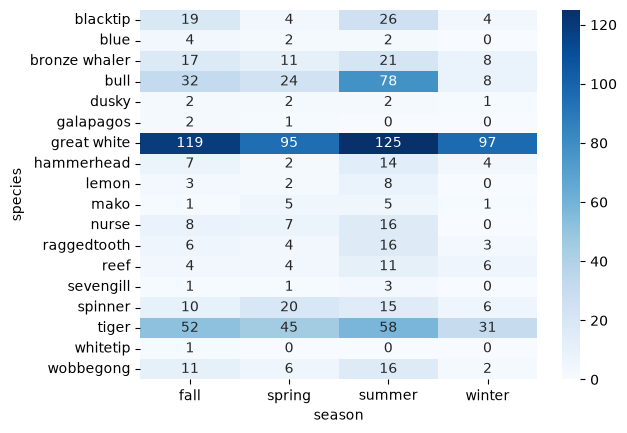

In [36]:
species_season_ct = pd.crosstab(shark_df["species"], shark_df["season"])

sns.heatmap(
    species_season_ct, 
    annot=True, 
    fmt="d", 
    cmap="Blues"
)
plt.show()

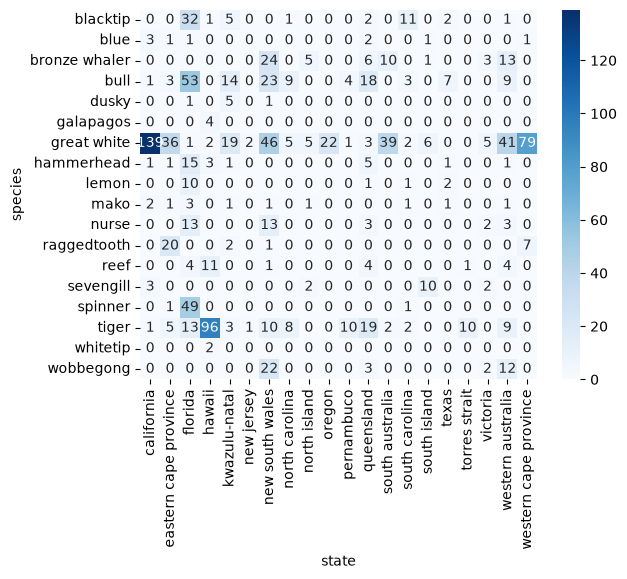

In [37]:
species_state_ct = pd.crosstab(shark_df["species"], shark_df["state"])

sns.heatmap(
    species_state_ct, 
    annot=True, 
    fmt="d", 
    cmap="Blues"
)
plt.show()

In [38]:
shark_df.to_csv("../data/clean_data/modeling_data.csv", index=False)